# Survival Analysis with Progenetix CNV Data

In this notebook, we build a simple survival analysis example using Progenetix data.

The basic workflow:

1. retrieve sample-level metadata,
2. retreive individual-level data with survival information,
3. retrieve sample-level CNV records,
4. convert CNV records into simple gene-level features,
5. and apply two standard survival analysis methods.

We will use:

- **Kaplan–Meier curves** to compare survival between two groups,
- and a **Cox proportional hazards model** to estimate how a CNV-derived feature is associated with hazard.



## Environment Setup

```bash
conda install -c conda-forge scikit-survival
pip install scikit-survival

In [ ]:
import requests
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io

from tqdm.auto import tqdm


from sksurv.util import Surv
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

/Users/lloyd/opt/anaconda3/envs/human_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Download sample metadata from Progenetix

We begin with the Progenetix `sampletable` service.

This service returns sample annotations in tabular form and supports query filters.
For example, the Progenetix documentation shows that TCGA samples can be retrieved with:

- `filters=pgx:cohort-TCGAcancers`

and that:

- `limit=0` means no result limit.


In [2]:
# -----------------------------
# Cohort definition
# -----------------------------
TARGET_TCGA_PROJECT = "pgx:TCGA-LIHC"   

# -----------------------------
# Progenetix sampletable endpoint
# -----------------------------
SAMPLETABLE_URL = "https://progenetix.org/services/sampletable/"

In [3]:
def fetch_sampletable(filters, limit=0, timeout=120):
    # Download a Progenetix sample table as a pandas DataFrame.
    params = {
        "filters": filters,
        "limit": limit,
    }

    response = requests.get(SAMPLETABLE_URL, params=params, timeout=timeout)
    response.raise_for_status()

    print("Status:", response.status_code)
    print("Final URL:", response.url)
    print("Content-Type:", response.headers.get("Content-Type"))

    text = response.text
    df = pd.read_csv(io.StringIO(text), sep="\t")
    return df

In [4]:
sample_table_df = fetch_sampletable(filters=TARGET_TCGA_PROJECT, limit=0)

print("Shape:", sample_table_df.shape)
print("Columns:")
print(sample_table_df.columns.tolist())
sample_table_df.head()

Status: 200
Final URL: https://progenetix.org/services/sampletable/?filters=pgx%3ATCGA-LIHC&limit=0
Content-Type: text/tsv
Shape: (767, 42)
Columns:
['biosample_id', 'individual_id', 'biosample_name', 'notes', 'histological_diagnosis_id', 'histological_diagnosis_label', 'pathological_stage_id', 'pathological_stage_label', 'biosample_status_id', 'biosample_status_label', 'sample_origin_type_id', 'sample_origin_type_label', 'sampled_tissue_id', 'sampled_tissue_label', 'tnm', 'tumor_grade_id', 'tumor_grade_label', 'age_iso', 'age_days', 'icdo_morphology_id', 'icdo_morphology_label', 'icdo_topography_id', 'icdo_topography_label', 'pubmed_id', 'pubmed_label', 'cellosaurus_id', 'cellosaurus_label', 'cbioportal_id', 'cbioportal_label', 'tcgaproject_id', 'tcgaproject_label', 'cohorts', 'geoprov_id', 'geoprov_city', 'geoprov_country', 'geoprov_iso_alpha3', 'geoprov_long_lat', 'followup_days', 'sex_id', 'sex_label', 'group_id', 'group_label']


,biosample_id,individual_id,biosample_name,notes,histological_diagnosis_id,histological_diagnosis_label,pathological_stage_id,pathological_stage_label,biosample_status_id,biosample_status_label,...,geoprov_id,geoprov_city,geoprov_country,geoprov_iso_alpha3,geoprov_long_lat,followup_days,sex_id,sex_label,group_id,group_label
0,pgxbs-kftvi0wf,pgxind-kftx3mop,6fdfd765-bbf7-4094-b5f9-3332e9514873,Primary Tumor,NCIT:C3099,Hepatocellular Carcinoma,NCIT:C27966,Stage I,EFO:0009656,neoplastic sample,...,houston::unitedstates::-95.36327::29.76328,Houston,United States,USA,-95.36327::29.76328,NaN,NaN,NaN,NaN,NaN
1,pgxbs-kftvhzfk,pgxind-kftx3qxj,56352822-d65f-46db-b549-c8a407a2e69f,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27966,Stage I,EFO:0009654,reference sample,...,houston::unitedstates::-95.36327::29.76328,Houston,United States,USA,-95.36327::29.76328,NaN,NaN,NaN,NaN,NaN
2,pgxbs-kftvi4cg,pgxind-kftx3kj3,bb9cfd7b-7ed8-4c42-a260-2ff15ff3c568,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C28054,Stage II,EFO:0009654,reference sample,...,houston::unitedstates::-95.36327::29.76328,Houston,United States,USA,-95.36327::29.76328,NaN,NaN,NaN,NaN,NaN
3,pgxbs-kftvi3qi,pgxind-kftx3t77,63552745-eb7f-4948-a552-05b77f645de4,Primary Tumor,NCIT:C3099,Hepatocellular Carcinoma,NCIT:C27982,Stage IIIC,EFO:0009656,neoplastic sample,...,houston::unitedstates::-95.36327::29.76328,Houston,United States,USA,-95.36327::29.76328,NaN,NaN,NaN,NaN,NaN
4,pgxbs-kftvi3bk,pgxind-kftx3p41,e5587496-5655-4b18-82e3-e00593a1c64c,Primary Tumor,NCIT:C3099,Hepatocellular Carcinoma,NCIT:C27982,Stage IIIC,EFO:0009656,neoplastic sample,...,houston::unitedstates::-95.36327::29.76328,Houston,United States,USA,-95.36327::29.76328,NaN,NaN,NaN,NaN,NaN


In [5]:
# Columns we want to keep from the sample table
BIOSAMPLE_COLUMNS = [
    "biosample_id",
    "individual_id",
    "biosample_name",
    "notes",
    "histological_diagnosis_id",
    "histological_diagnosis_label",
    "pathological_stage_id",
    "pathological_stage_label",
    "sample_origin_type_id",
    "sample_origin_type_label",
    "sampled_tissue_id",
    "sampled_tissue_label",
    "tcgaproject_id",
    "tcgaproject_label",
    "icdo_morphology_id",
    "icdo_topography_id",
    "icdo_topography_label",
]

BIOSAMPLE_COLUMNS = [c for c in BIOSAMPLE_COLUMNS if c in sample_table_df.columns]

biosample_df = sample_table_df[BIOSAMPLE_COLUMNS].copy()

print("Biosample-level metadata shape:", biosample_df.shape)
biosample_df.head()

Biosample-level metadata shape: (767, 17)


,biosample_id,individual_id,biosample_name,notes,histological_diagnosis_id,histological_diagnosis_label,pathological_stage_id,pathological_stage_label,sample_origin_type_id,sample_origin_type_label,sampled_tissue_id,sampled_tissue_label,tcgaproject_id,tcgaproject_label,icdo_morphology_id,icdo_topography_id,icdo_topography_label
0,pgxbs-kftvi0wf,pgxind-kftx3mop,6fdfd765-bbf7-4094-b5f9-3332e9514873,Primary Tumor,NCIT:C3099,Hepatocellular Carcinoma,NCIT:C27966,Stage I,OBI:0001479,specimen from organism,UBERON:0002107,liver,pgx:TCGA-LIHC,Hepatocellular Carcinoma,pgx:icdom-81703,pgx:icdot-C22.0,Liver
1,pgxbs-kftvhzfk,pgxind-kftx3qxj,56352822-d65f-46db-b549-c8a407a2e69f,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27966,Stage I,OBI:0001479,specimen from organism,UBERON:0000178,blood,pgx:TCGA-LIHC,Hepatocellular Carcinoma,pgx:icdom-00000,pgx:icdot-C42.0,Blood
2,pgxbs-kftvi4cg,pgxind-kftx3kj3,bb9cfd7b-7ed8-4c42-a260-2ff15ff3c568,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C28054,Stage II,OBI:0001479,specimen from organism,UBERON:0000178,blood,pgx:TCGA-LIHC,Hepatocellular Carcinoma,pgx:icdom-00000,pgx:icdot-C42.0,Blood
3,pgxbs-kftvi3qi,pgxind-kftx3t77,63552745-eb7f-4948-a552-05b77f645de4,Primary Tumor,NCIT:C3099,Hepatocellular Carcinoma,NCIT:C27982,Stage IIIC,OBI:0001479,specimen from organism,UBERON:0002107,liver,pgx:TCGA-LIHC,Hepatocellular Carcinoma,pgx:icdom-81703,pgx:icdot-C22.0,Liver
4,pgxbs-kftvi3bk,pgxind-kftx3p41,e5587496-5655-4b18-82e3-e00593a1c64c,Primary Tumor,NCIT:C3099,Hepatocellular Carcinoma,NCIT:C27982,Stage IIIC,OBI:0001479,specimen from organism,UBERON:0002107,liver,pgx:TCGA-LIHC,Hepatocellular Carcinoma,pgx:icdom-81703,pgx:icdot-C22.0,Liver


## Build survival metadata by combining biosample- and individual-level information

The Progenetix sample table is useful for cohort selection and biosample-level metadata, but survival-related information is not always available there.

In our case, each biosample is linked to an `individual_id`.  
We therefore use a two-step strategy:

1. retrieve **biosample-level metadata** from the Progenetix sample table,
2. retrieve **individual-level follow-up metadata** from the Progenetix individual endpoint,
3. and merge the two through `individual_id`.

This is important because survival analysis requires at least:

- a follow-up time,
- and an event indicator.

These fields are available in the individual-level record.

In the Progenetix data model, one individual may have more than one biosample.  
Therefore, after merging biosample- and individual-level metadata, we also need to decide how to handle the one-to-many relationship before building a survival model.

In [6]:
individual_ids = (
    biosample_df["individual_id"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

print("Number of unique individuals:", len(individual_ids))
print(individual_ids[:10])

Number of unique individuals: 376
['pgxind-kftx3mop', 'pgxind-kftx3qxj', 'pgxind-kftx3kj3', 'pgxind-kftx3t77', 'pgxind-kftx3p41', 'pgxind-kftx3w2v', 'pgxind-kftx3gyo', 'pgxind-kftx3tk3', 'pgxind-kftx3p54', 'pgxind-kftx3t33']


In [7]:
SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json, text/plain, */*",
})

def fetch_individual_record(individual_id, session=SESSION, timeout=120):
    # Fetch one Progenetix individual record by individual ID.
    url = f"https://progenetix.org/beacon/individuals/{individual_id}/"
    response = session.get(url, timeout=timeout)
    response.raise_for_status()
    return response.json()

In [8]:
def parse_individual_record(data):
    # Parse one Progenetix individual JSON response into a flat dictionary.
    response = data.get("response", {})
    result_sets = response.get("resultSets", [])
    if not result_sets:
        return None

    results = result_sets[0].get("results", [])
    if not results:
        return None

    rec = results[0]

    diseases = rec.get("diseases", [])
    disease_0 = diseases[0] if len(diseases) > 0 else {}

    out = {
        # identifiers
        "individual_id": rec.get("id"),
        "n_diseases": len(diseases),

        # sex
        "sex_id_individual": rec.get("sex", {}).get("id"),
        "sex_label_individual": rec.get("sex", {}).get("label"),

        # top-level survival-related status
        "vital_status": rec.get("vitalStatus", {}).get("status"),

        # top-level info block
        "info_age_at_diagnosis_days": rec.get("info", {}).get("ageAtDiagnosis"),
        "info_days_to_death": rec.get("info", {}).get("daysToDeath"),
        "info_death": rec.get("info", {}).get("death"),
        "info_ethnicity": rec.get("info", {}).get("ethnicity"),
        "info_race": rec.get("info", {}).get("race"),
        "info_year_of_birth": rec.get("info", {}).get("yearOfBirth"),

        # references
        "tcga_case_id": rec.get("references", {}).get("tcgacase", {}).get("id"),
        "tcga_submitter_id": rec.get("references", {}).get("tcgasubmitter", {}).get("id"),

        # disease block 
        "disease_id": disease_0.get("diseaseCode", {}).get("id"),
        "disease_label": disease_0.get("diseaseCode", {}).get("label"),
        "followup_days": disease_0.get("followupDays"),
        "followup_time_iso": disease_0.get("followupTime"),
        "followup_state_id": disease_0.get("followupState", {}).get("id"),
        "followup_state_label": disease_0.get("followupState", {}).get("label"),
        "onset_age_iso": disease_0.get("onset", {}).get("age"),
        "onset_age_days": disease_0.get("onset", {}).get("ageDays"),
        "stage_id_individual": disease_0.get("stage", {}).get("id"),
        "stage_label_individual": disease_0.get("stage", {}).get("label"),
    }

    return out

In [10]:
individual_rows = []
failed_individuals = []

for individual_id in tqdm(individual_ids, desc="Fetching individual records"):
    try:
        data = fetch_individual_record(individual_id)
        row = parse_individual_record(data)
        if row is not None:
            individual_rows.append(row)
        else:
            failed_individuals.append((individual_id, "No result"))
    except Exception as e:
        failed_individuals.append((individual_id, str(e)))

individual_df = pd.DataFrame(individual_rows)

print("Fetched individual rows:", len(individual_df))
print("Failed individual queries:", len(failed_individuals))
individual_df.head()

Fetching individual records: 100%|██████████| 376/376 [09:24<00:00,  1.50s/it]

Fetched individual rows: 376
Failed individual queries: 0


,individual_id,n_diseases,sex_id_individual,sex_label_individual,vital_status,info_age_at_diagnosis_days,info_days_to_death,info_death,info_ethnicity,info_race,...,disease_id,disease_label,followup_days,followup_time_iso,followup_state_id,followup_state_label,onset_age_iso,onset_age_days,stage_id_individual,stage_label_individual
0,pgxind-kftx3mop,1,NCIT:C20197,male,ALIVE,18695.0,NaN,alive,not hispanic or latino,asian,...,NCIT:C3099,HePATOcellular Carcinoma,638.0,P21M,EFO:0030041,alive (follow-up status),P51Y2M6D,18694.0,NCIT:C27966,Stage I
1,pgxind-kftx3qxj,1,NCIT:C20197,male,ALIVE,24221.0,NaN,alive,not hispanic or latino,asian,...,NCIT:C3099,HePATOcellular Carcinoma,669.0,P22M,EFO:0030041,alive (follow-up status),P66Y3M23D,24220.0,NCIT:C27966,Stage I
2,pgxind-kftx3kj3,1,NCIT:C20197,male,ALIVE,21985.0,NaN,alive,not hispanic or latino,white,...,NCIT:C3099,HePATOcellular Carcinoma,334.0,P11M,EFO:0030041,alive (follow-up status),P60Y2M9D,21984.0,NCIT:C28054,Stage II
3,pgxind-kftx3t77,1,NCIT:C20197,male,ALIVE,22457.0,NaN,alive,not hispanic or latino,white,...,NCIT:C3099,HePATOcellular Carcinoma,517.0,P17M,EFO:0030041,alive (follow-up status),P61Y5M24D,22455.0,NCIT:C27982,Stage IIIC
4,pgxind-kftx3p41,1,NCIT:C16576,female,ALIVE,21946.0,NaN,alive,not hispanic or latino,asian,...,NCIT:C3099,HePATOcellular Carcinoma,243.0,P8M,EFO:0030041,alive (follow-up status),P60Y1M0D,21944.0,NCIT:C27982,Stage IIIC


### Merge Biosample and Individual with individual_id

In [13]:
merged_meta_df = biosample_df.merge(
    individual_df,
    on="individual_id",
    how="left"
)

print("Merged metadata shape:", merged_meta_df.shape)
merged_meta_df.head()

Merged metadata shape: (767, 39)


,biosample_id,individual_id,biosample_name,notes,histological_diagnosis_id,histological_diagnosis_label,pathological_stage_id,pathological_stage_label,sample_origin_type_id,sample_origin_type_label,...,disease_id,disease_label,followup_days,followup_time_iso,followup_state_id,followup_state_label,onset_age_iso,onset_age_days,stage_id_individual,stage_label_individual
0,pgxbs-kftvi0wf,pgxind-kftx3mop,6fdfd765-bbf7-4094-b5f9-3332e9514873,Primary Tumor,NCIT:C3099,Hepatocellular Carcinoma,NCIT:C27966,Stage I,OBI:0001479,specimen from organism,...,NCIT:C3099,HePATOcellular Carcinoma,638.0,P21M,EFO:0030041,alive (follow-up status),P51Y2M6D,18694.0,NCIT:C27966,Stage I
1,pgxbs-kftvhzfk,pgxind-kftx3qxj,56352822-d65f-46db-b549-c8a407a2e69f,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27966,Stage I,OBI:0001479,specimen from organism,...,NCIT:C3099,HePATOcellular Carcinoma,669.0,P22M,EFO:0030041,alive (follow-up status),P66Y3M23D,24220.0,NCIT:C27966,Stage I
2,pgxbs-kftvi4cg,pgxind-kftx3kj3,bb9cfd7b-7ed8-4c42-a260-2ff15ff3c568,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C28054,Stage II,OBI:0001479,specimen from organism,...,NCIT:C3099,HePATOcellular Carcinoma,334.0,P11M,EFO:0030041,alive (follow-up status),P60Y2M9D,21984.0,NCIT:C28054,Stage II
3,pgxbs-kftvi3qi,pgxind-kftx3t77,63552745-eb7f-4948-a552-05b77f645de4,Primary Tumor,NCIT:C3099,Hepatocellular Carcinoma,NCIT:C27982,Stage IIIC,OBI:0001479,specimen from organism,...,NCIT:C3099,HePATOcellular Carcinoma,517.0,P17M,EFO:0030041,alive (follow-up status),P61Y5M24D,22455.0,NCIT:C27982,Stage IIIC
4,pgxbs-kftvi3bk,pgxind-kftx3p41,e5587496-5655-4b18-82e3-e00593a1c64c,Primary Tumor,NCIT:C3099,Hepatocellular Carcinoma,NCIT:C27982,Stage IIIC,OBI:0001479,specimen from organism,...,NCIT:C3099,HePATOcellular Carcinoma,243.0,P8M,EFO:0030041,alive (follow-up status),P60Y1M0D,21944.0,NCIT:C27982,Stage IIIC


### Build Survival Outcome
Keep one biosample for each individual

In [14]:
survival_df = merged_meta_df.copy()

# Survival time
survival_df["time"] = pd.to_numeric(survival_df["followup_days"], errors="coerce")

def map_event(row):
    """
    Convert individual-level follow-up / vital status into a binary event label.
    0 = alive / censored
    1 = dead / event occurred
    """
    followup_state = str(row.get("followup_state_label", "")).strip().lower()
    vital_status = str(row.get("vital_status", "")).strip().upper()

    if "alive" in followup_state:
        return 0
    if "deceased" in followup_state or "dead" in followup_state:
        return 1

    if vital_status == "ALIVE":
        return 0
    if vital_status == "DECEASED":
        return 1

    return np.nan

survival_df["event"] = survival_df.apply(map_event, axis=1)

# Keep only rows with usable survival data
survival_df = survival_df.dropna(subset=["biosample_id", "individual_id", "time", "event"]).copy()
survival_df["event"] = survival_df["event"].astype(int)

print("Rows with usable survival data:", len(survival_df))
survival_df[[
    "biosample_id",
    "individual_id",
    "time",
    "event",
    "followup_state_label",
    "vital_status",
    "sex_label_individual"
]].head()

Rows with usable survival data: 568


,biosample_id,individual_id,time,event,followup_state_label,vital_status,sex_label_individual
0,pgxbs-kftvi0wf,pgxind-kftx3mop,638.0,0,alive (follow-up status),ALIVE,male
1,pgxbs-kftvhzfk,pgxind-kftx3qxj,669.0,0,alive (follow-up status),ALIVE,male
2,pgxbs-kftvi4cg,pgxind-kftx3kj3,334.0,0,alive (follow-up status),ALIVE,male
3,pgxbs-kftvi3qi,pgxind-kftx3t77,517.0,0,alive (follow-up status),ALIVE,male
4,pgxbs-kftvi3bk,pgxind-kftx3p41,243.0,0,alive (follow-up status),ALIVE,female


## Plotting sample type distribution for filtering

,sample_type,count
0,Primary Tumor,282
1,Blood Derived Normal,248
2,Solid Tissue Normal,35
3,Recurrent Tumor,3


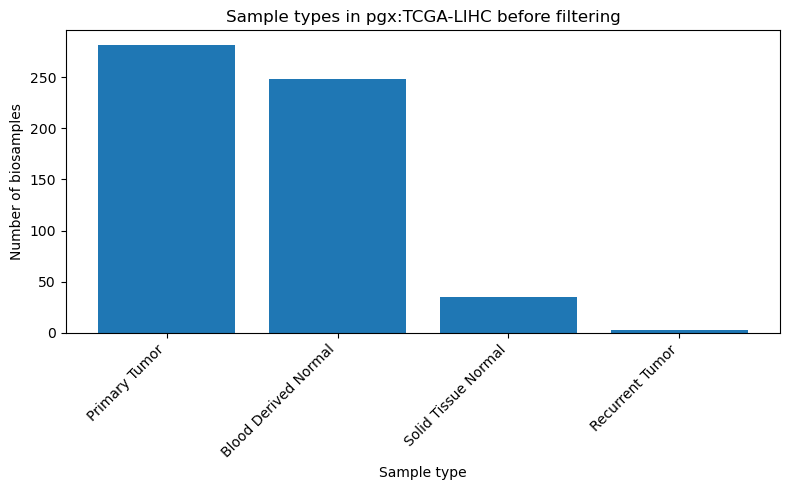

In [41]:
import matplotlib.pyplot as plt

sample_type_counts = (
    survival_df["notes"]
    .fillna("Unknown")
    .value_counts()
    .reset_index()
)

sample_type_counts.columns = ["sample_type", "count"]

display(sample_type_counts)

plt.figure(figsize=(8, 5))
plt.bar(sample_type_counts["sample_type"], sample_type_counts["count"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Sample type")
plt.ylabel("Number of biosamples")
plt.title(f"Sample types in {TARGET_TCGA_PROJECT} before filtering")
plt.tight_layout()
plt.show()

In [15]:
# Keep only primary tumor samples for the survival/CNV analysis
tumor_df = survival_df[
    survival_df["notes"].astype(str).str.contains("Primary Tumor", case=False, na=False)
].copy()

print("Rows after keeping only Primary Tumor samples:", len(tumor_df))
print("Individuals after Primary Tumor filtering:", tumor_df["individual_id"].nunique())

# Keep one primary tumor biosample per individual
survival_unique_df = (
    tumor_df
    .sort_values(["individual_id", "biosample_id"])
    .groupby("individual_id", as_index=False)
    .head(1)
    .copy()
)

print("Rows after keeping one primary tumor biosample per individual:", len(survival_unique_df))
survival_unique_df[[
    "biosample_id",
    "individual_id",
    "sample_origin_type_label",
    "notes",
    "time",
    "event",
    "sex_label_individual"
]].head()

Rows after keeping only Primary Tumor samples: 282
Individuals after Primary Tumor filtering: 282
Rows after keeping one primary tumor biosample per individual: 282


,biosample_id,individual_id,sample_origin_type_label,notes,time,event,sex_label_individual
556,pgxbs-kftvhhi4,pgxind-kftx3f7l,specimen from organism,Primary Tumor,517.0,0,male
347,pgxbs-kftvhhk8,pgxind-kftx3fa3,specimen from organism,Primary Tumor,212.0,0,male
91,pgxbs-kftvi6r6,pgxind-kftx3fb9,specimen from organism,Primary Tumor,912.0,0,male
40,pgxbs-kftvhhov,pgxind-kftx3ffp,specimen from organism,Primary Tumor,0.0,1,female
701,pgxbs-kftvhhpy,pgxind-kftx3fgz,specimen from organism,Primary Tumor,2311.0,0,female


In [16]:
FINAL_META_COLUMNS = [
    # biosample-level
    "biosample_id",
    "individual_id",
    "biosample_name",
    "notes",
    "histological_diagnosis_id",
    "histological_diagnosis_label",
    "pathological_stage_id",
    "pathological_stage_label",
    "sample_origin_type_id",
    "sample_origin_type_label",
    "sampled_tissue_id",
    "sampled_tissue_label",
    "tcgaproject_id",
    "tcgaproject_label",
    "icdo_morphology_id",
    "icdo_topography_id",
    "icdo_topography_label",

    # individual-level
    "sex_id_individual",
    "sex_label_individual",
    "vital_status",
    "info_age_at_diagnosis_days",
    "info_days_to_death",
    "info_death",
    "info_ethnicity",
    "info_race",
    "info_year_of_birth",
    "tcga_case_id",
    "tcga_submitter_id",
    "disease_id",
    "disease_label",
    "followup_days",
    "followup_time_iso",
    "followup_state_id",
    "followup_state_label",
    "onset_age_iso",
    "onset_age_days",
    "stage_id_individual",
    "stage_label_individual",

    # derived survival variables
    "time",
    "event",
]

FINAL_META_COLUMNS = [c for c in FINAL_META_COLUMNS if c in survival_unique_df.columns]

survival_unique_df = survival_unique_df[FINAL_META_COLUMNS].copy()

print("Final survival metadata shape:", survival_unique_df.shape)
survival_unique_df.head()

Final survival metadata shape: (282, 40)


,biosample_id,individual_id,biosample_name,notes,histological_diagnosis_id,histological_diagnosis_label,pathological_stage_id,pathological_stage_label,sample_origin_type_id,sample_origin_type_label,...,followup_days,followup_time_iso,followup_state_id,followup_state_label,onset_age_iso,onset_age_days,stage_id_individual,stage_label_individual,time,event
556,pgxbs-kftvhhi4,pgxind-kftx3f7l,63a726a2-46cd-48dc-bab7-195b16fb0f25,Primary Tumor,NCIT:C3099,Hepatocellular Carcinoma,NCIT:C27966,Stage I,OBI:0001479,specimen from organism,...,517.0,P17M,EFO:0030041,alive (follow-up status),P66Y4M4D,24231.0,NCIT:C27966,Stage I,517.0,0
347,pgxbs-kftvhhk8,pgxind-kftx3fa3,729ca3a4-1c6b-4c84-b4ce-150bb21d631d,Primary Tumor,NCIT:C3099,Hepatocellular Carcinoma,NCIT:C28054,Stage II,OBI:0001479,specimen from organism,...,212.0,P7M,EFO:0030041,alive (follow-up status),P55Y2M7D,20156.0,NCIT:C28054,Stage II,212.0,0
91,pgxbs-kftvi6r6,pgxind-kftx3fb9,30f43a40-040f-4c42-a84e-0ba7ec9c8945,Primary Tumor,NCIT:C3099,Hepatocellular Carcinoma,NCIT:C27966,Stage I,OBI:0001479,specimen from organism,...,912.0,P30M,EFO:0030041,alive (follow-up status),P57Y3M3D,20913.0,NCIT:C27966,Stage I,912.0,0
40,pgxbs-kftvhhov,pgxind-kftx3ffp,bc90ead3-1a92-49c8-9d97-ef4a8751833a,Primary Tumor,NCIT:C3099,Hepatocellular Carcinoma,NCIT:C27977,Stage IIIA,OBI:0001479,specimen from organism,...,0.0,P0M,EFO:0030049,dead (follow-up status),P51Y5M16D,18795.0,NCIT:C27977,Stage IIIA,0.0,1
701,pgxbs-kftvhhpy,pgxind-kftx3fgz,b6104862-f135-46a7-86a4-1e12b96386e6,Primary Tumor,NCIT:C3099,Hepatocellular Carcinoma,NCIT:C27966,Stage I,OBI:0001479,specimen from organism,...,2311.0,P76M,EFO:0030041,alive (follow-up status),P74Y2M13D,27101.0,NCIT:C27966,Stage I,2311.0,0


## Retrieve full CNV records and derive gene-level features locally

We use the record-level endpoint:

- retrieve all CNV records for each retained biosample,
- identify which CNV intervals overlap the target gene,
- and summarize those overlaps into simple binary features.

For the target gene, we define:

- `EGFR_hit`: at least one CNV overlaps the EGFR locus
- `EGFR_gain_hit`: at least one overlapping CNV is a gain
- `EGFR_loss_hit`: at least one overlapping CNV is a loss



In [17]:
TARGET_GENE = "TP53"

GENE_COORDS = {
    "TP53": {
        "chromosome": "17",
        "start": 7668421,
        "end": 7687490,
    }
}

gene_info = GENE_COORDS[TARGET_GENE]
print(TARGET_GENE, gene_info)

TP53 {'chromosome': '17', 'start': 7668421, 'end': 7687490}


## Define helper functions

We now define helper functions to:

1. retrieve full CNV records for one biosample,
2. extract the record list from the Beacon response,
3. test whether a CNV interval overlaps the target gene,
4. classify the CNV state as gain or loss,
5. and summarize all records for one biosample into three binary gene-level features.

In [18]:
SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json, text/plain, */*",
})

def fetch_biosample_variants_record(biosample_id, session=SESSION, timeout=120):
    """
    Fetch all CNV variant records for one biosample from the
    biosample-scoped Progenetix g_variants endpoint.
    """
    url = f"https://progenetix.org/beacon/biosamples/{biosample_id}/g_variants/"
    params = {
        "requestedGranularity": "record"
    }
    response = session.get(url, params=params, timeout=timeout)
    response.raise_for_status()
    return response.json()

In [19]:
def extract_variant_results(data):
    # Extract the list of variant records from a Beacon JSON response.
    response = data.get("response", {})
    result_sets = response.get("resultSets", [])

    if not result_sets:
        return []

    return result_sets[0].get("results", [])

In [20]:
#helper functions for overlap and state parsing

def intervals_overlap(start1, end1, start2, end2):
    # Return True if two genomic intervals overlap.
    return (start1 <= end2) and (start2 <= end1)


def classify_copy_change(label):
    """
    Reduce CNV state labels into broader categories.

    Output categories:
    - gain
    - loss
    - other
    """
    if not isinstance(label, str):
        return "other"

    x = label.strip().lower()

    if "gain" in x or "high-level gain" in x or "low-level gain" in x:
        return "gain"
    if "loss" in x or "high-level loss" in x or "low-level loss" in x:
        return "loss"

    return "other"

## Summarize one biosample into EGFR-based binary features

For each biosample, we scan all returned CNV records and check:

- whether the record is on the same chromosome as EGFR,
- whether the CNV interval overlaps the EGFR locus,
- and whether the overlapping CNV is classified as gain or loss.

From this, we build three simple Boolean features:

- `EGFR_hit`
- `EGFR_gain_hit`
- `EGFR_loss_hit`

In [21]:
def summarize_gene_features_from_records(records, gene_name, gene_info):
    """
    Summarize all CNV records for one biosample into three binary features:
    - GENE_hit
    - GENE_gain_hit
    - GENE_loss_hit
    """
    gene_chr = str(gene_info["chromosome"])
    gene_start = int(gene_info["start"])
    gene_end = int(gene_info["end"])

    features = {
        f"{gene_name}_hit": 0,
        f"{gene_name}_gain_hit": 0,
        f"{gene_name}_loss_hit": 0,
    }

    for item in records:
        variation = item.get("variation", {})
        location = variation.get("location", {})

        chrom = str(location.get("chromosome"))
        start = location.get("start")
        end = location.get("end")

        if chrom != gene_chr:
            continue
        if start is None or end is None:
            continue

        if not intervals_overlap(start, end, gene_start, gene_end):
            continue

        # At least one overlapping CNV exists
        features[f"{gene_name}_hit"] = 1

        # Prefer copyChange, fallback to variantState.label
        state_label = variation.get("copyChange")
        if state_label is None:
            state_label = variation.get("variantState", {}).get("label")

        state = classify_copy_change(state_label)

        if state == "gain":
            features[f"{gene_name}_gain_hit"] = 1
        elif state == "loss":
            features[f"{gene_name}_loss_hit"] = 1

    return features

### Debug function to inspect one biosample

In [22]:
def inspect_gene_overlaps_for_one_biosample(biosample_id, gene_name, gene_info):
    # Debug helper: print overlapping CNV records for one biosample.

    data = fetch_biosample_variants_record(biosample_id)
    records = extract_variant_results(data)

    gene_chr = str(gene_info["chromosome"])
    gene_start = int(gene_info["start"])
    gene_end = int(gene_info["end"])

    overlaps = []

    for item in records:
        variation = item.get("variation", {})
        location = variation.get("location", {})

        chrom = str(location.get("chromosome"))
        start = location.get("start")
        end = location.get("end")

        if chrom != gene_chr:
            continue
        if start is None or end is None:
            continue
        if not intervals_overlap(start, end, gene_start, gene_end):
            continue

        overlaps.append({
            "chromosome": chrom,
            "start": start,
            "end": end,
            "copyChange": variation.get("copyChange"),
            "variantStateLabel": variation.get("variantState", {}).get("label"),
        })

    return pd.DataFrame(overlaps)

In [39]:
test_biosample_id = survival_unique_df["biosample_id"].iloc[1]
test = inspect_gene_overlaps_for_one_biosample(test_biosample_id, TARGET_GENE, gene_info)
test.shape

(1, 5)

## Build EGFR features for all retained biosamples

We now apply the same logic to all retained biosamples.

For each biosample, we:
- retrieve the full CNV record set once,
- derive EGFR overlap features locally,
- and store the results in a compact biosample-level feature table.

In [24]:
def build_gene_feature_table_from_records(biosample_ids, gene_name, gene_info):
    """
    Build a biosample-level feature table by querying full record data
    and summarizing gene overlap features locally.
    """
    rows = []
    failures = []

    for biosample_id in tqdm(biosample_ids, desc=f"Building {gene_name} features from record data"):
        try:
            data = fetch_biosample_variants_record(biosample_id)
            records = extract_variant_results(data)

            features = summarize_gene_features_from_records(records, gene_name, gene_info)
            features["biosample_id"] = biosample_id
            rows.append(features)

        except Exception as e:
            failures.append((biosample_id, str(e)))
            rows.append({
                "biosample_id": biosample_id,
                f"{gene_name}_hit": np.nan,
                f"{gene_name}_gain_hit": np.nan,
                f"{gene_name}_loss_hit": np.nan,
            })

    feature_df = pd.DataFrame(rows)
    return feature_df, failures

In [25]:
biosample_ids_for_features = survival_unique_df["biosample_id"].dropna().astype(str).tolist()

gene_feature_df, gene_feature_failures = build_gene_feature_table_from_records(
    biosample_ids=biosample_ids_for_features,
    gene_name=TARGET_GENE,
    gene_info=gene_info
)

print("Feature table shape:", gene_feature_df.shape)
print("Number of failed biosample queries:", len(gene_feature_failures))
gene_feature_df.head()

Building TP53 features from record data: 100%|██████████| 282/282 [07:31<00:00,  1.60s/it]

Feature table shape: (282, 4)
Number of failed biosample queries: 0


,TP53_hit,TP53_gain_hit,TP53_loss_hit,biosample_id
0,0,0,0,pgxbs-kftvhhi4
1,1,0,1,pgxbs-kftvhhk8
2,0,0,0,pgxbs-kftvi6r6
3,1,1,0,pgxbs-kftvhhov
4,1,0,1,pgxbs-kftvhhpy


In [26]:
# inspect failures if needed 

if len(gene_feature_failures) > 0:
    print("Example failures:")
    print(gene_feature_failures[:10])
else:
    print("No failures detected.")

No failures detected.


## Merge EGFR features into the survival metadata

We now merge the EGFR-derived biosample features back into the survival metadata table.

This gives us a final analysis table containing:

- one retained biosample per individual,
- survival time,
- event status,
- and the three EGFR-based CNV features.

In [ ]:
analysis_df = survival_unique_df.merge(
    gene_feature_df,
    on="biosample_id",
    how="left"
)

feature_cols = [
    f"{TARGET_GENE}_hit",
    f"{TARGET_GENE}_gain_hit",
    f"{TARGET_GENE}_loss_hit",
]

analysis_df[feature_cols] = analysis_df[feature_cols].fillna(0).astype(int)

print("Analysis table shape:", analysis_df.shape)
analysis_df.head()


Analysis table shape: (282, 43)


,biosample_id,individual_id,biosample_name,notes,histological_diagnosis_id,histological_diagnosis_label,pathological_stage_id,pathological_stage_label,sample_origin_type_id,sample_origin_type_label,...,followup_state_label,onset_age_iso,onset_age_days,stage_id_individual,stage_label_individual,time,event,TP53_hit,TP53_gain_hit,TP53_loss_hit
0,pgxbs-kftvhhi4,pgxind-kftx3f7l,63a726a2-46cd-48dc-bab7-195b16fb0f25,Primary Tumor,NCIT:C3099,Hepatocellular Carcinoma,NCIT:C27966,Stage I,OBI:0001479,specimen from organism,...,alive (follow-up status),P66Y4M4D,24231.0,NCIT:C27966,Stage I,517.0,0,0,0,0
1,pgxbs-kftvhhk8,pgxind-kftx3fa3,729ca3a4-1c6b-4c84-b4ce-150bb21d631d,Primary Tumor,NCIT:C3099,Hepatocellular Carcinoma,NCIT:C28054,Stage II,OBI:0001479,specimen from organism,...,alive (follow-up status),P55Y2M7D,20156.0,NCIT:C28054,Stage II,212.0,0,1,0,1
2,pgxbs-kftvi6r6,pgxind-kftx3fb9,30f43a40-040f-4c42-a84e-0ba7ec9c8945,Primary Tumor,NCIT:C3099,Hepatocellular Carcinoma,NCIT:C27966,Stage I,OBI:0001479,specimen from organism,...,alive (follow-up status),P57Y3M3D,20913.0,NCIT:C27966,Stage I,912.0,0,0,0,0
3,pgxbs-kftvhhov,pgxind-kftx3ffp,bc90ead3-1a92-49c8-9d97-ef4a8751833a,Primary Tumor,NCIT:C3099,Hepatocellular Carcinoma,NCIT:C27977,Stage IIIA,OBI:0001479,specimen from organism,...,dead (follow-up status),P51Y5M16D,18795.0,NCIT:C27977,Stage IIIA,0.0,1,1,1,0
4,pgxbs-kftvhhpy,pgxind-kftx3fgz,b6104862-f135-46a7-86a4-1e12b96386e6,Primary Tumor,NCIT:C3099,Hepatocellular Carcinoma,NCIT:C27966,Stage I,OBI:0001479,specimen from organism,...,alive (follow-up status),P74Y2M13D,27101.0,NCIT:C27966,Stage I,2311.0,0,1,0,1


In [28]:
# check for feature distribution
for col in feature_cols:
    print(f"\n{col}")
    print(analysis_df[col].value_counts(dropna=False))


TP53_hit
TP53_hit
1    156
0    126
Name: count, dtype: int64

TP53_gain_hit
TP53_gain_hit
0    274
1      8
Name: count, dtype: int64

TP53_loss_hit
TP53_loss_hit
1    142
0    140
Name: count, dtype: int64


In [78]:
analysis_df.columns

Index(['biosample_id', 'individual_id', 'histological_diagnosis_label',
       'tcgaproject_label', 'sample_origin_type_label', 'sex_label_individual',
       'stage_label_individual', 'followup_days', 'followup_time_iso',
       'followup_state_label', 'vital_status', 'time', 'event', 'TP53_hit',
       'TP53_gain_hit', 'TP53_loss_hit'],
      dtype='object')

In [29]:
# final data
FINAL_ANALYSIS_COLUMNS = [
    "biosample_id",
    "individual_id",
    "histological_diagnosis_label",
    "tcgaproject_label",
    "sample_origin_type_label",
    "sex_label_individual",
    "stage_label_individual",
    "followup_days",
    "followup_time_iso",
    "followup_state_label",
    "vital_status",
    "time",
    "event",
    f"{TARGET_GENE}_hit",
    f"{TARGET_GENE}_gain_hit",
    f"{TARGET_GENE}_loss_hit",
]

FINAL_ANALYSIS_COLUMNS = [c for c in FINAL_ANALYSIS_COLUMNS if c in analysis_df.columns]
analysis_df = analysis_df[FINAL_ANALYSIS_COLUMNS].copy()

analysis_df.head()

,biosample_id,individual_id,histological_diagnosis_label,tcgaproject_label,sample_origin_type_label,sex_label_individual,stage_label_individual,followup_days,followup_time_iso,followup_state_label,vital_status,time,event,TP53_hit,TP53_gain_hit,TP53_loss_hit
0,pgxbs-kftvhhi4,pgxind-kftx3f7l,Hepatocellular Carcinoma,Hepatocellular Carcinoma,specimen from organism,male,Stage I,517.0,P17M,alive (follow-up status),ALIVE,517.0,0,0,0,0
1,pgxbs-kftvhhk8,pgxind-kftx3fa3,Hepatocellular Carcinoma,Hepatocellular Carcinoma,specimen from organism,male,Stage II,212.0,P7M,alive (follow-up status),ALIVE,212.0,0,1,0,1
2,pgxbs-kftvi6r6,pgxind-kftx3fb9,Hepatocellular Carcinoma,Hepatocellular Carcinoma,specimen from organism,male,Stage I,912.0,P30M,alive (follow-up status),ALIVE,912.0,0,0,0,0
3,pgxbs-kftvhhov,pgxind-kftx3ffp,Hepatocellular Carcinoma,Hepatocellular Carcinoma,specimen from organism,female,Stage IIIA,0.0,P0M,dead (follow-up status),DECEASED,0.0,1,1,1,0
4,pgxbs-kftvhhpy,pgxind-kftx3fgz,Hepatocellular Carcinoma,Hepatocellular Carcinoma,specimen from organism,female,Stage I,2311.0,P76M,alive (follow-up status),ALIVE,2311.0,0,1,0,1


## Kaplan–Meier survival analysis

We first use Kaplan–Meier curves to compare survival between groups.

It directly estimates survival probability over time for different groups.

Here we use one Boolean gene-level CNV feature to define the groups, for example:

- `EGFR_hit = 1` versus `EGFR_hit = 0`
- or `EGFR_gain_hit = 1` versus `EGFR_gain_hit = 0`
- or `EGFR_loss_hit = 1` versus `EGFR_loss_hit = 0`

This provides a visual first impression of whether the feature may be associated with different survival patterns.

try EGFR_gain_hit

In [49]:
KM_FEATURE = f"{TARGET_GENE}_gain_hit"
print("Kaplan–Meier grouping feature:", KM_FEATURE)

analysis_df[[KM_FEATURE, "time", "event"]].head()

Kaplan–Meier grouping feature: TP53_gain_hit


,TP53_gain_hit,time,event
0,0,517.0,0
1,0,212.0,0
2,0,912.0,0
3,1,0.0,1
4,0,2311.0,0


## Plot Kaplan–Meier curves

We now divide the samples into two groups based on the selected feature:

- group 0: feature absent
- group 1: feature present

We then estimate and plot survival curves for both groups.

In [50]:
group_0 = analysis_df[analysis_df[KM_FEATURE] == 0].copy()
group_1 = analysis_df[analysis_df[KM_FEATURE] == 1].copy()

print("Group sizes")
print("-----------")
print(f"{KM_FEATURE} = 0 :", len(group_0))
print(f"{KM_FEATURE} = 1 :", len(group_1))

Group sizes
-----------
TP53_gain_hit = 0 : 274
TP53_gain_hit = 1 : 8


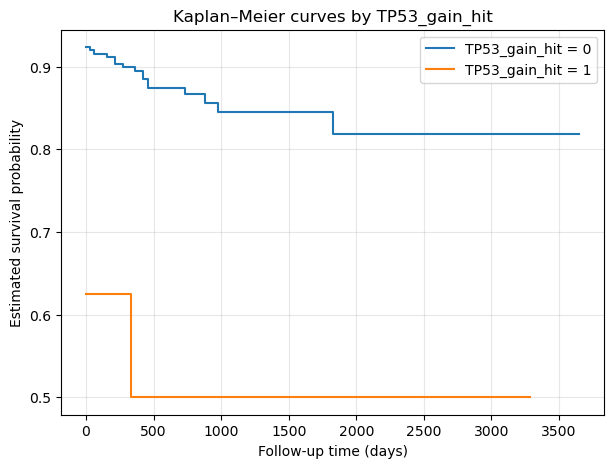

In [51]:
plt.figure(figsize=(7, 5))

for group_df, label in [
    (group_0, f"{KM_FEATURE} = 0"),
    (group_1, f"{KM_FEATURE} = 1"),
]:
    if len(group_df) == 0:
        continue

    time, survival_prob = kaplan_meier_estimator(
        event=group_df["event"].astype(bool),
        time_exit=group_df["time"].astype(float),
    )

    plt.step(time, survival_prob, where="post", label=label)

plt.xlabel("Follow-up time (days)")
plt.ylabel("Estimated survival probability")
plt.title(f"Kaplan–Meier curves by {KM_FEATURE}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Plot KM for any feature

In [52]:
def plot_km_for_feature(df, feature_col, title=None):
    # Plot Kaplan–Meier curves for a binary feature column.
    
    plt.figure(figsize=(7, 5))

    for value in [0, 1]:
        group_df = df[df[feature_col] == value].copy()
        if len(group_df) == 0:
            continue

        time, survival_prob = kaplan_meier_estimator(
            event=group_df["event"].astype(bool),
            time_exit=group_df["time"].astype(float),
        )

        plt.step(time, survival_prob, where="post", label=f"{feature_col} = {value}")

    plt.xlabel("Follow-up time (days)")
    plt.ylabel("Estimated survival probability")
    plt.title(title if title is not None else f"Kaplan–Meier curves by {feature_col}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

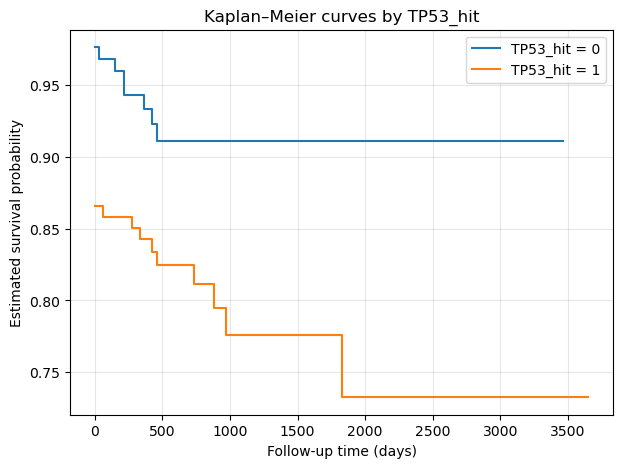

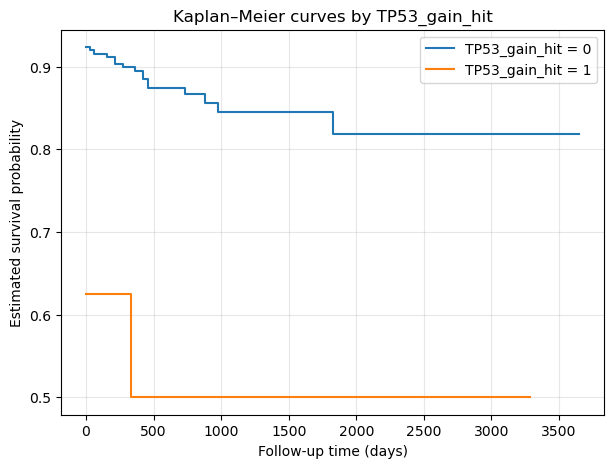

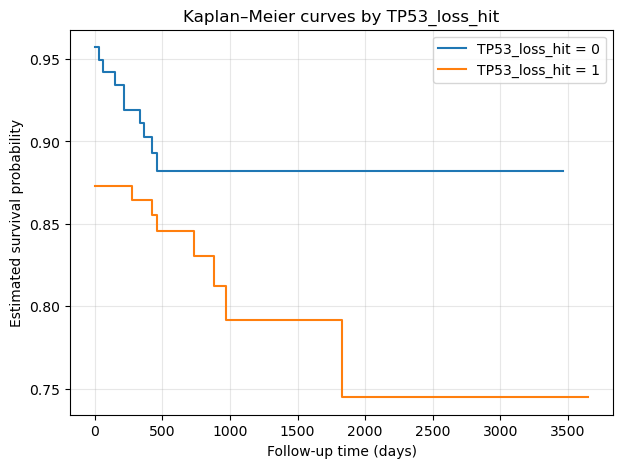

In [53]:
for feature_col in [
    f"{TARGET_GENE}_hit",
    f"{TARGET_GENE}_gain_hit",
    f"{TARGET_GENE}_loss_hit",
]:
    plot_km_for_feature(analysis_df, feature_col)

In [55]:
for feature in ["TP53_hit", "TP53_gain_hit", "TP53_loss_hit"]:
    print("\n", feature)
    print(analysis_df[feature].value_counts(dropna=False))

    tmp = (
        analysis_df
        .groupby(feature)
        .agg(
            n=("time", "size"),
            deaths=("event", "sum"),
            median_time=("time", "median"),
            min_time=("time", "min"),
            max_time=("time", "max")
        )
    )
    display(tmp)


 TP53_hit
TP53_hit
1    156
0    126
Name: count, dtype: int64


,n,deaths,median_time,min_time,max_time
TP53_hit,,,,,
0,126,10,608.0,0.0,3467.0
1,156,30,547.0,0.0,3650.0



 TP53_gain_hit
TP53_gain_hit
0    274
1      8
Name: count, dtype: int64


,n,deaths,median_time,min_time,max_time
TP53_gain_hit,,,,,
0,274,36,577.0,0.0,3650.0
1,8,4,364.5,0.0,3285.0



 TP53_loss_hit
TP53_loss_hit
1    142
0    140
Name: count, dtype: int64


,n,deaths,median_time,min_time,max_time
TP53_loss_hit,,,,,
0,140,15,608.0,0.0,3467.0
1,142,25,547.0,0.0,3650.0


In [56]:
death_df = analysis_df[analysis_df["event"] == 1].copy()

death_cols = [
    "individual_id",
    "biosample_id",
    "time",
    "TP53_hit",
    "TP53_gain_hit",
    "TP53_loss_hit",
    "age_at_diagnosis",
    "age_years",
    "sex_label_individual",
    "pathological_stage_label",
    "clinical_stage_label",
    "histological_diagnosis_label",
]

death_cols = [c for c in death_cols if c in death_df.columns]

death_df[death_cols].sort_values(
    ["TP53_loss_hit", "TP53_gain_hit", "time"],
    ascending=[False, False, True]
)

,individual_id,biosample_id,time,TP53_hit,TP53_gain_hit,TP53_loss_hit,sex_label_individual,histological_diagnosis_label
9,pgxind-kftx3frb,pgxbs-kftvi8nj,0.0,1,0,1,female,Hepatocellular Carcinoma
32,pgxind-kftx3hgh,pgxbs-kftvhjew,0.0,1,0,1,female,Hepatocellular Carcinoma
41,pgxind-kftx3hyx,pgxbs-kftvhjv1,0.0,1,0,1,male,Hepatocellular Carcinoma
68,pgxind-kftx3k2e,pgxbs-kftvhls2,0.0,1,0,1,male,Hepatocellular Carcinoma
108,pgxind-kftx3mn8,pgxbs-kftvhtxy,0.0,1,0,1,male,Hepatocellular Carcinoma
136,pgxind-kftx3okz,pgxbs-kftvhq9x,0.0,1,0,1,male,Hepatocellular Carcinoma
151,pgxind-kftx3p1y,pgxbs-kftvhqws,0.0,1,0,1,female,Hepatocellular Carcinoma
171,pgxind-kftx3qj1,pgxbs-kftvhsu3,0.0,1,0,1,male,Hepatocellular Carcinoma
175,pgxind-kftx3qqp,pgxbs-kftvht5i,0.0,1,0,1,male,Hepatocellular Carcinoma
186,pgxind-kftx3rmm,pgxbs-kftvi88c,0.0,1,0,1,male,Hepatocellular Carcinoma


In [59]:


stage_col = "stage_label_individual"

stage_df = analysis_df[
    analysis_df["time"].notna()
    & analysis_df["event"].notna()
    & (analysis_df["time"] > 0)
    & analysis_df[stage_col].notna()
].copy()

stage_df = stage_df[
    ~stage_df[stage_col].astype(str).str.contains("unknown|not reported|nan", case=False, na=False)
].copy()

stage_df[stage_col].value_counts()

stage_label_individual
Stage I       127
Stage II       60
Stage IIIA     33
Stage IIIB      5
Stage IIIC      5
Stage III       1
Name: count, dtype: int64

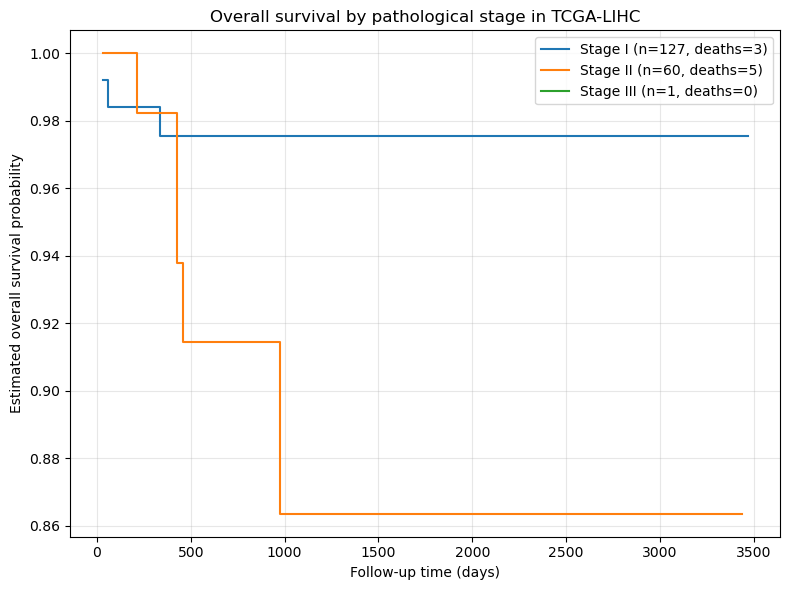

In [60]:
import matplotlib.pyplot as plt
from sksurv.nonparametric import kaplan_meier_estimator

plt.figure(figsize=(8, 6))

stage_order = ["Stage I", "Stage II", "Stage III", "Stage IV"]

for stage in stage_order:
    group_df = stage_df[stage_df[stage_col] == stage]

    if len(group_df) == 0:
        continue

    time, survival_prob = kaplan_meier_estimator(
        event=group_df["event"].astype(bool),
        time_exit=group_df["time"].astype(float)
    )

    plt.step(
        time,
        survival_prob,
        where="post",
        label=f"{stage} (n={len(group_df)}, deaths={group_df['event'].sum()})"
    )

plt.xlabel("Follow-up time (days)")
plt.ylabel("Estimated overall survival probability")
plt.title("Overall survival by pathological stage in TCGA-LIHC")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
summary_by_loss = (
    analysis_df
    .groupby("TP53_loss_hit")
    .agg(
        n=("time", "size"),
        deaths=("event", "sum"),
        death_rate=("event", "mean"),
        median_followup_days=("time", "median"),
        median_age_at_diagnosis=("age_at_diagnosis", "median")
            if "age_at_diagnosis" in analysis_df.columns else ("time", "median"),
    )
)

summary_by_loss

,n,deaths,death_rate,median_followup_days,median_age_at_diagnosis
TP53_loss_hit,,,,,
0,140,15,0.107143,608.0,608.0
1,142,25,0.176056,547.0,547.0


## Cox proportional hazards model

Kaplan–Meier curves are useful for visual comparison, but they do not provide a regression-based estimate of effect size.

We therefore also fit a Cox proportional hazards model.

The Cox model estimates how each feature is associated with hazard over time.  
The fitted coefficient can be interpreted as follows:

- positive coefficient → higher hazard
- negative coefficient → lower hazard

If we exponentiate the coefficient, we obtain a **hazard ratio**.

## Choose Cox model covariates

We begin with:

- one Boolean CNV feature for the target gene,
- and optionally one covariate such as sex.


In [77]:
cox_df = analysis_df.copy()

# Encode sex as a simple binary covariate if available
# Here we encode:
# female -> 0
# male   -> 1
# all other / missing -> NaN, then drop or impute
if "sex_label_individual" in cox_df.columns:
    sex_map = {
        "female": 0,
        "male": 1,
    }
    cox_df["sex_binary"] = (
        cox_df["sex_label_individual"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(sex_map)
    )
else:
    cox_df["sex_binary"] = np.nan


stage_map = {
    "Stage I": 1,
    "Stage IA": 1,
    "Stage IB": 1,
    "Stage II": 2,
    "Stage IIA": 2,
    "Stage IIB": 2,
    "Stage III": 3,
    "Stage IIIA": 3,
    "Stage IIIB": 3,
    "Stage IIIC": 3,
    "Stage IV": 4,
    "Stage IVA": 4,
    "Stage IVB": 4,
}

cox_df["stage_numeric"] = cox_df["stage_label_individual"].map(stage_map)

[c for c in cox_df.columns]


['biosample_id',
 'individual_id',
 'histological_diagnosis_label',
 'tcgaproject_label',
 'sample_origin_type_label',
 'sex_label_individual',
 'stage_label_individual',
 'followup_days',
 'followup_time_iso',
 'followup_state_label',
 'vital_status',
 'time',
 'event',
 'TP53_hit',
 'TP53_gain_hit',
 'TP53_loss_hit',
 'sex_binary',
 'stage_numeric']

In [76]:
COX_FEATURES = [
    f"{TARGET_GENE}_gain_hit",
    f"{TARGET_GENE}_loss_hit",
    "sex_binary",
    "stage_numeric",

    
]




cox_model_df = cox_df.dropna(subset=["time", "event"] + COX_FEATURES).copy()

X = cox_model_df[COX_FEATURES].astype(float).copy()

y = Surv.from_arrays(
    event=cox_model_df["event"].astype(bool),
    time=cox_model_df["time"].astype(float),
)

cox_model = CoxPHSurvivalAnalysis()
cox_model.fit(X, y)

coef_df = pd.DataFrame({
    "feature": COX_FEATURES,
    "coefficient": cox_model.coef_,
    "hazard_ratio": np.exp(cox_model.coef_),
})

coef_df

,feature,coefficient,hazard_ratio
0,TP53_gain_hit,1.618925,5.047661
1,TP53_loss_hit,0.689602,1.992923
2,sex_binary,-0.109009,0.896722
3,stage_numeric,1.139325,3.124657


## Visualize Cox model results

The Cox model coefficients can be transformed into hazard ratios by exponentiation.

In the plot below:

- a hazard ratio of **1** indicates no association,
- values **greater than 1** indicate higher hazard,
- values **less than 1** indicate lower hazard.


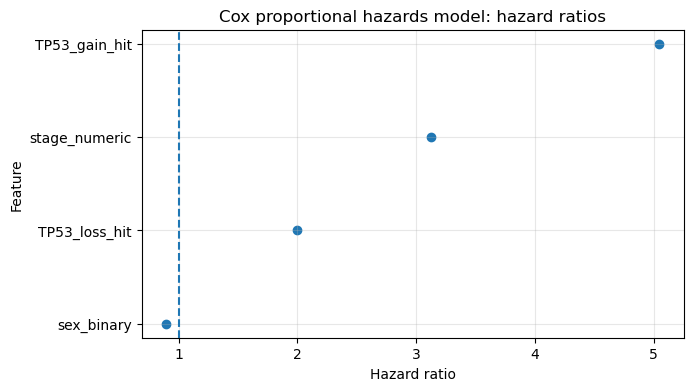

In [69]:
plt.figure(figsize=(7, 4))

plot_df = coef_df.sort_values("hazard_ratio").reset_index(drop=True)
y_pos = np.arange(len(plot_df))

plt.scatter(plot_df["hazard_ratio"], y_pos)
plt.axvline(1.0, linestyle="--")

plt.yticks(y_pos, plot_df["feature"])
plt.xlabel("Hazard ratio")
plt.ylabel("Feature")
plt.title("Cox proportional hazards model: hazard ratios")
plt.grid(alpha=0.3)
plt.show()

## Concordance index

The concordance index (C-index) measures how well the Cox model ranks samples by risk.

It can be interpreted as a survival-specific ranking metric:

- **0.5** means the model performs no better than random ranking,
- values **closer to 1** indicate better discrimination,
- and values **below 0.5** suggest that the model ranks risk poorly.

Importantly, the C-index is not the same as classification accuracy.  
It evaluates whether samples predicted to be at higher risk tend to experience the event earlier.

In [38]:
# calculate concordance index

risk_scores = cox_model.predict(X)

cindex = concordance_index_censored(
    event_indicator=cox_model_df["event"].astype(bool),
    event_time=cox_model_df["time"].astype(float),
    estimate=risk_scores,
)

print("Concordance index:", cindex[0])

Concordance index: 0.6351666666666667


The concordance index is approximately **0.60**.

This suggests that the Cox model has **modest discriminatory ability**:
it performs better than random ranking, but the predictive signal is still limited.

This is not surprising in the current notebook, because the model is intentionally simple and uses only a small number of interpretable features.  

## Summary


This survival analysis notebook shows how to move from:

1. biosample-level metadata,
2. to individual-level follow-up information,
3. to biosample-level CNV records,
4. to gene-level Boolean features,
5. and finally to survival analysis.